Based on GEN-MIX-1-NANG_Fast_test-v2

Run this cell to install the latest version:

In [ ]:
! pip install git+ssh://git@github.com/pim-n/pg-rad.git@dev --force-reinstall

  Cloning ssh://****@github.com/pim-n/pg-rad.git (to revision dev) to /tmp/pip-req-build-o6cv8h6y
  Running command git clone --filter=blob:none --quiet 'ssh://****@github.com/pim-n/pg-rad.git' /tmp/pip-req-build-o6cv8h6y


In [1]:
import os
import pymc as pm
import random
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns
import pytensor.tensor as tt

from pathlib import Path
from pytensor import function
from scipy.signal import find_peaks
from typing import List, Tuple, Callable, Dict

In [2]:
BASE_DIR = Path("__file__").resolve().parent
ATTENUATION_FILE = Path(BASE_DIR.joinpath("./tools/attenuation_table.csv"))

#SIM_FOLDER = "./data/2_sources_straight_road_result_20260415_0958/"
#ROI_FILENAME = "1_2_src_15_cps_bkg_1000MBq_1000MBq_50m_50m_308_50_708_50.csv"

SIM_FOLDER = "./data/2_sources_straight_road_result_20260416_1349/"
ROI_FILENAME = "1_2_src_15_cps_bkg_1000MBq_1000MBq_32m_32m_308_32_708_32.csv"

CSV_DIR = Path(BASE_DIR.joinpath(SIM_FOLDER))

In [3]:
from tools.utils import return_efficiency_filename_path
from tools.interpolators import AttenuationInterpolator
from tools.tensor_interpolator import interpolate1d

In [4]:
print(f"Verison of pymc: {pm.__version__}")

Verison of pymc: 5.28.2


#### 📄Description
This is a new model utilizes a Poisson distribution to estimate the count rate. This is a stable version of the model

<h4>⚠️Changed activity prior distribution to LogNormal</h4>
<h5>🔬 How to Test New Model Configurations </h5>
- Perform tests on extreme datasets: 100 MBq and 10,000 MBq</br>
- Remove noise and angular effects (these should be added at the final stage of testing)</br>
- Modify one parameter at a time to clearly track its impact</br>

#### 👉 Change here

In [5]:
N_CHAINS = 2
indexes = None

#### Helping functions

In [6]:
params_file = Path(CSV_DIR.joinpath("parameters.json"))
params_file
params = json.load(params_file.open())
params

{'name': '2 sources straight road',
 'size': [1008.0, 1008.0],
 'detector': {'name': 'LU_NaI_3inch',
  'type': 'NaI',
  'is_isotropic': True,
  'field_eff': 0.0020677034872822733},
 'sources': [{'name': 's1',
   'isotope': 'Cs137',
   'primary_gamma': 661.657,
   'activity': 1000.0,
   'position': [308.33, 32.0, 0.0],
   'dist_from_path': 32.0},
  {'name': 's2',
   'isotope': 'Cs137',
   'primary_gamma': 661.657,
   'activity': 1000.0,
   'position': [708.3299999999999, 32.0, 0.0],
   'dist_from_path': 32.0}]}

In [7]:
# Constant values
DETECTOR = "NaIR"
NUM_SOURCE = len(params['sources'])
SCALE = 1e6
BRANCH_RATIO = 0.851
AIR_DENSITY = 1.243
CORRECTION_COEFFICIENT = 0.1
SOURCE_ENERGY = params['sources'][0]['primary_gamma']
DET_EFF = params['detector']['field_eff']
simnum = 2000
burnin = 500

In [33]:
def set_parameters(raw_data, params, idxs=None, n_sources=NUM_SOURCE):
    cps = raw_data.ROI_P
    if idxs:
        peaks = idxs
    else:
        distance = len(cps) // 2
        while distance > 0:
            peaks, _  = find_peaks(cps, distance=distance, prominence=float(np.std(cps)))
            if len(peaks) < n_sources:
                print("[*] Peaks not found. Retrying...")
                distance -= max(1, distance // 5)
            else:
                break
           
    bkg_array = raw_data.ROI_BR
    params_ = {
        "MEAN_BKG_CPS": bkg_array.mean(),
        "BKG_STD": bkg_array.std(),
        "X_POS": raw_data["East"].values,
        "Y_POS": raw_data["North"].values,
        "MAX_X": [],
        "MAX_Y": [],
        "max_cps": [],
        "cps": cps.values,
        "LOWER_X": -params["size"][0],
        "UPPER_X": params["size"][0],
        "LOWER_Y": -params["size"][1],
        "UPPER_Y": params["size"][1],
        "indexes": peaks
    }
    for _, idx in enumerate(peaks):
        params_["MAX_X"].append(raw_data.East[idx])
        params_["MAX_Y"].append(raw_data.North[idx])
        params_["max_cps"].append(raw_data.ROI_P[idx])
        
    return params_

def parse_filename(fname: str, number_of_sources: int = 1):
    """
    The function extracts real parameters from filename. It's sensitive for valid naming
    Example of valid naming: 1_2_src_45_cps_bkg_1000MBq_1000MBq_100m_100m_1325154_6187254_1325890_6187934.csv
    Returns:
        real_params: dict
        indx: integer
        delta_dist: string
    """
    num_of_params = {1: 10, 2: 14, 3: 18}
    if isinstance(fname, str):
        fname = Path(fname)
        
    try:
        frags = fname.stem.split("_")
        params_list = fname.stem.split("_")
        print(len(params_list), num_of_params.get(number_of_sources))
        assert len(params_list) == num_of_params.get(number_of_sources)        
    except AssertionError:
        raise
    else:
        params_list = params_list[1:]
        coords_parse = params_list[-number_of_sources*2:] if number_of_sources > 0 else []
        act_parse = params_list[5:5+number_of_sources]
        dist_parse = [int(x.strip('m')) for x in params_list if "m" in x]

        real_params = {}
        for i in range(number_of_sources):
            x_src = coords_parse[2*i]
            y_src = coords_parse[2*i+1]
            act = int(act_parse[i][:-3])
            distance = dist_parse[i]
    
            real_params[i+1] = {"x": int(x_src), "y": int(y_src), "act": act, "dist": distance}
    
        return real_params

In [34]:
def plot_base_distribution(x: np.ndarray, cps: np.ndarray, max_x: List[int]) -> None:
    """
    The function create a cps base distribution
    params: x - coordinates or length of the detector's trajectory
            cps - count rate
            max_x - x coordinate where the maximum count rate appeared
    return: None
    """
    spines = ["right", "top"]
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x, cps, color="b", linewidth=1)
    for spine in spines:
        ax.spines[spine].set_visible(False)

    if max_x:
        for index in max_x:
            ax.axvline(index, linestyle="--", color="r")
    ax.set_ylabel("CPS", fontsize=14)
    plt.show()


def plot_act_density(samples: dict, true_act=None):
    n_rows = len(samples)
    fig, axes = plt.subplots(n_rows, 1, figsize=(12, 6), sharex=True, squeeze=False)
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        ax.spines.top.set_visible(False)
        ax.spines.right.set_visible(False)
        ax.spines.bottom.set_color("black")
        ax.spines.left.set_color("black")
        ax.set_ylabel("Density", fontsize=14)
        ax.grid(False)
        ax.axvline(true_act[i], color="red", linestyle="--")
        sns.kdeplot(samples[i+1], fill=True, color="b", ax=axes[i])
        
    axes[-1].set_xlabel("Activity, MBq", fontsize=14)      
    plt.show()


def plot_location(
    data,
    src_x_real,
    src_y_real,
    merged_x,
    merged_y
):
    x_coords = data.East
    y_coords = data.North

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_coords, y_coords, color="b", linewidth=1)
    ax.scatter(src_x_real, src_y_real, color="black", marker="^")

    n_sources = merged_x.shape[0]
    colors = ["r", "orange", "green", "purple"]

    for s in range(n_sources):
        ax.scatter(
            merged_x[s][::10],
            merged_y[s][::10],
            color=colors[s % len(colors)],
            marker="x",
            alpha=0.6
        )
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.grid(True, alpha=0.5)
    plt.show()
    

def build_coordinates(x_array, y_array, num_sources):
    return list(zip(x_array[:num_sources],
                    y_array[:num_sources]))


def standardize_coordinates(
    coords: List[np.ndarray],
    scale: float = None
) -> Tuple[List[np.ndarray], Dict[str, np.ndarray], Callable, Callable]:
    """
    Standardizes coordinate arrays.

    Parameters
    ----------
    coords : List[np.ndarray]
        List of coordinate arrays (e.g. [x_array, y_array]).
    scale : float, optional
        If provided, use this fixed scale instead of std.

    Returns
    -------
    coords_std : List[np.ndarray]
        Standardized coordinates.
    params : dict
        Dictionary with means and scales for inverse transform.
    to_original : function
        Function to convert standardized values back.
    to_standardized : function
        Function to convert new raw values to standardized space.
    """

    coords = [np.asarray(c, dtype=float) for c in coords]
    means = np.array([np.mean(c) for c in coords])

    if scale is None:
        scales = np.array([np.std(c) for c in coords])
    else:
        scales = np.array([scale for _ in coords])

    # Avoid division by zero
    scales = np.where(scales == 0, 1.0, scales)
    coords_stand = [(c - m) / s for c, m, s in zip(coords, means, scales)]

    params = {
        "means": means,
        "scales": scales
    }

    def to_original(values: List[np.ndarray]) -> List[np.ndarray]:
        return [
            v * s + m
            for v, m, s in zip(values, means, scales)
        ]

    def to_standardized(values: List[np.ndarray]) -> List[np.ndarray]:
        return [
            (v - m) / s
            for v, m, s in zip(values, means, scales)
        ]

    return coords_stand, params, to_original, to_standardized

#### Loading data

In [35]:
csv_file = Path(CSV_DIR.joinpath(ROI_FILENAME))
csv_file

PosixPath('/home/pim/pg-rad-analysis/bayesian/data/2_sources_straight_road_result_20260416_1349/1_2_src_15_cps_bkg_1000MBq_1000MBq_32m_32m_308_32_708_32.csv')

In [36]:
df = pd.read_csv(csv_file)
df.head()

,East,North,ROI_P,ROI_BR,Dist
0,8.33,0.0,0.000000,14.81,0.00
1,16.66,0.0,13.191729,14.81,8.33
2,24.99,0.0,14.254391,14.81,16.66
3,33.32,0.0,13.817691,14.81,24.99
4,41.65,0.0,15.034593,14.81,33.32


In [37]:
attenuation_df = pd.read_csv(ATTENUATION_FILE)
attenuation_interpolator = AttenuationInterpolator(attenuation_df)
mu_air = attenuation_interpolator.interpolate(SOURCE_ENERGY)  # mu_air = 0.0015
mu_air *= CORRECTION_COEFFICIENT * AIR_DENSITY
print(mu_air)

0.009636447511845


In [38]:
eff_file_path = return_efficiency_filename_path(DETECTOR)
eff_df = pd.read_csv(eff_file_path)
eff_df.head()

,Angle,E_rel_662_90
0,0,0.027
1,10,0.162
2,20,0.346
3,30,0.517
4,40,0.662


#### Setup parameters for models

In [39]:
real_params = parse_filename(csv_file, number_of_sources=NUM_SOURCE)
init_params = set_parameters(df, params, idxs=indexes)
MEAN_BKG_CPS = init_params["MEAN_BKG_CPS"]
BKG_STD = init_params["BKG_STD"]
max_cps = init_params["max_cps"]
MAX_X = init_params["MAX_X"]
MAX_Y = init_params["MAX_Y"]
X_POS = init_params["X_POS"]
Y_POS = init_params["Y_POS"]

LOWER_X = init_params["LOWER_X"]
UPPER_X = init_params["UPPER_X"]
LOWER_Y = init_params["LOWER_Y"]
UPPER_Y = init_params["UPPER_Y"]

cps = init_params["cps"]
max_idxs = init_params["indexes"]
ref_coords_x = [real_params[j+1].get("x") for j in range(len(real_params))]
ref_coords_y = [real_params[j+1].get("y") for j in range(len(real_params))]
max_coordinates = build_coordinates(MAX_X, MAX_Y, NUM_SOURCE)
true_acts = [real_params[i+1]["act"] for i in range(len(real_params))]

# coords_stand, params, to_original, to_standardized = standardize_coordinates(to_convert)
print(f"INDEXES:\t{max_idxs},\nMEAN_BKG_CPS:\t{MEAN_BKG_CPS},\nMAX_CPS:\t{max_cps},\nBKG_STD:\t{BKG_STD},\nMAX_X:\t{MAX_X},\nMAX_Y:\t{MAX_Y},\nLOWER_X:\t{LOWER_X},\nUPPER_X:\t{UPPER_X},\nLOWER_Y:\t{LOWER_Y},\nUPPER_Y:\t{UPPER_Y}")
print(f"Real coords:\t{ref_coords_x, ref_coords_y}")
print(f"Max coords:\t{max_coordinates}")

# if NUM_SOURCE != len(max_idxs):
#     NUM_SOURCE = len(max_idxs)
#     print(f"[!] Number of sources set to:\t{NUM_SOURCE}")

14 14
[*] Peaks not found. Retrying...
INDEXES:	[36 84],
MEAN_BKG_CPS:	14.81,
MAX_CPS:	[np.float64(101.14952176428554), np.float64(102.44725457709424)],
BKG_STD:	0.0,
MAX_X:	[np.float64(308.21), np.float64(708.05)],
MAX_Y:	[np.float64(0.0), np.float64(0.0)],
LOWER_X:	-1008.0,
UPPER_X:	1008.0,
LOWER_Y:	-1008.0,
UPPER_Y:	1008.0
Real coords:	([308, 708], [32, 32])
Max coords:	[(np.float64(308.21), np.float64(0.0)), (np.float64(708.05), np.float64(0.0))]


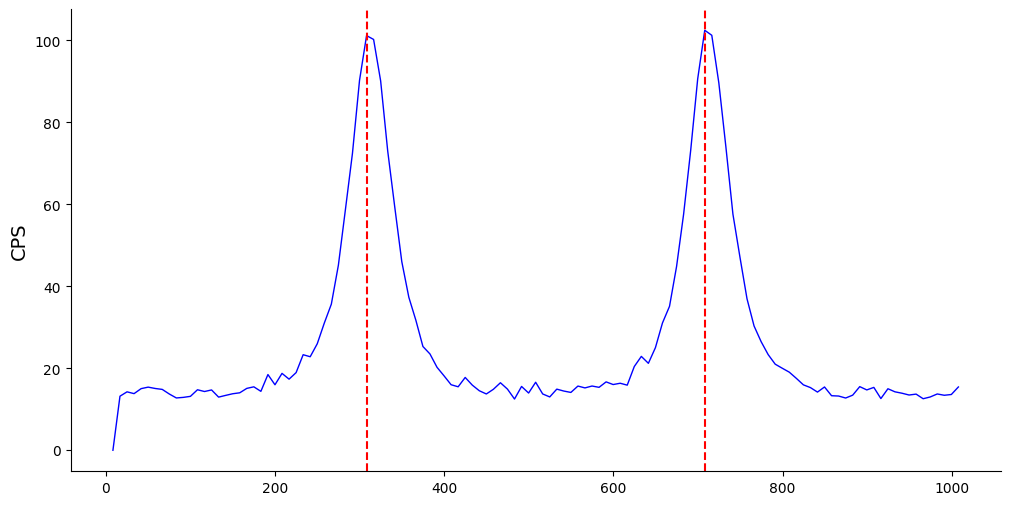

In [40]:
plot_base_distribution(X_POS, cps, MAX_X)

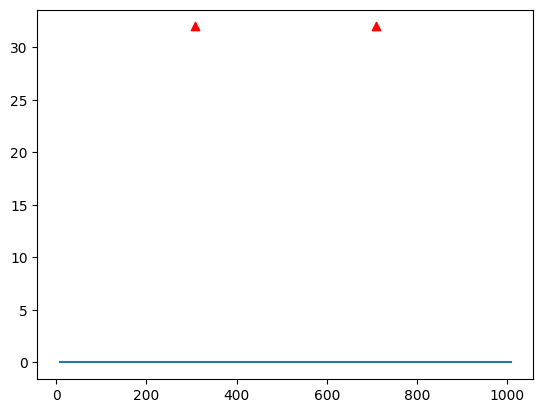

In [41]:
plt.plot(X_POS, Y_POS)
plt.scatter(ref_coords_x, ref_coords_y, marker="^", color="r")
plt.show()

In [42]:
angle_grid = eff_df.Angle.values
efficiency = eff_df.E_rel_662_90.values

In [43]:
angle_grid = angle_grid.astype("float64")

In [44]:
f_inter_tt = interpolate1d(angle_grid, efficiency)

#### Setup models

In [45]:
def mean_cps_tt(**kwargs):

    src_x = kwargs["x"]
    src_y = kwargs["y"]
    acts = kwargs["acts"]

    x_pos = kwargs["x_position"]
    y_pos = kwargs["y_position"]

    r_detector_sq = x_pos**2 + y_pos**2
    
    dist = tt.sqrt(
        r_detector_sq +
        src_x[:, None]**2 +
        src_y[:, None]**2 -
        2 * (x_pos * src_x[:, None] + y_pos * src_y[:, None])
    )
    dist = tt.clip(dist, 1e-3, 1e6)
    rate = (acts[:, None] * SCALE * BRANCH_RATIO * DET_EFF *
            tt.exp(-mu_air * dist)) / (4 * tt.pi * dist**2)

    return rate

In [46]:
def build_model(
    x_pos, y_pos,
    lower_x, upper_x,
    lower_y, upper_y,
    mean_bkg, bkg_std,
    cps,
    coordinates,
    prior_activity=1000,
    no_init_val=False
):
    pos_x_tt = tt.as_tensor_variable(x_pos, dtype="float64")
    pos_y_tt = tt.as_tensor_variable(y_pos, dtype="float64")

    coordinates = np.asarray(coordinates)
    x_init = coordinates[:, 0]
    y_init = coordinates[:, 1]

    y_init = [y+1e-3 if np.isclose(0, y) else y for y in y_init]
    sources = {"sources": range(NUM_SOURCE)}

    with pm.Model(coords=sources) as model:
        data = pm.Data("observed_cps", cps)
        if np.isclose(bkg_std, 0.0):
            bkg = mean_bkg
        else:
            sigma_bkg = pm.HalfNormal("sigma_bkg", bkg_std)
            bkg = pm.TruncatedNormal(
                "bkg",
                mu=mean_bkg,
                sigma=sigma_bkg,
                lower=0
            )

        if no_init_val:
            x = pm.Uniform("x_src", lower=lower_x, upper=upper_x, dims="sources")
            y = pm.Uniform("y_src", lower=lower_y, upper=upper_y, dims="sources")
        else:
            y = pm.Uniform("y_src", lower=lower_y, upper=upper_y, dims="sources", initval=y_init)
            x = pm.Uniform("x_src", lower=lower_x, upper=upper_x, dims="sources", initval=x_init)
        
        activity = pm.LogNormal(
            "act_src",
            mu=np.log(prior_activity),
            sigma=2,   # широкий 0.7 or 1.2 more wide
            dims="sources"
        )

        source_cps = mean_cps_tt(
            x_position=pos_x_tt,
            y_position=pos_y_tt,
            x=x,
            y=y,
            acts=activity
        )

        mu_total = source_cps.sum(axis=0) + bkg
        mu_total = tt.clip(mu_total, 1e-6, 1e9) # protection from zeros
        pm.Poisson(
            "predicted_cps",
            mu=mu_total,
            observed=data
        )

    return model

In [47]:

model = build_model(
    X_POS, Y_POS,
    LOWER_X, UPPER_X, 
    LOWER_Y, UPPER_Y,
    MEAN_BKG_CPS, BKG_STD,
    cps,
    max_coordinates,
    no_init_val=False
)

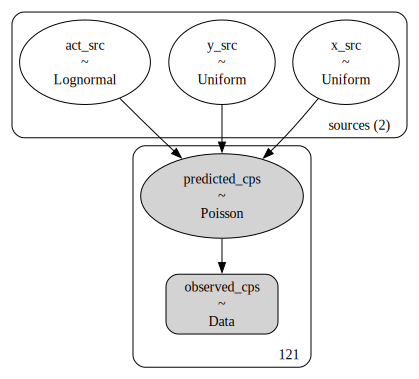

In [48]:
model.to_graphviz()

In [49]:
seed = random.randint(10, 10000)
rng = np.random.default_rng()
with model:
    trace = pm.sample(
        simnum,
        tune=burnin,
        discard_tuned_samples=True,
        chains=N_CHAINS,
        cores=min(N_CHAINS, 2),
        target_accept=0.95,
        random_seed=[seed + i for i in range(N_CHAINS)]
    )
    ppc = pm.sample_posterior_predictive(trace, random_seed=seed)
    trace.extend(ppc)

/home/pim/miniforge3/envs/pg-rad-analysis/lib/python3.12/site-packages/pymc/sampling/mcmc.py:786: UserWarning: A list or tuple of random_seed no longer specifies the specific random_seed of each chain. Use a single seed instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [y_src, x_src, act_src]


Output()

Sampling 2 chains for 500 tune and 2_000 draw iterations (1_000 + 4_000 draws total) took 6 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [predicted_cps]


Output()

In [29]:
az.summary(trace, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
y_src[0],29.47,2.12,25.62,33.60,0.05,0.04,1742.26,1894.07,1.0
y_src[1],29.28,2.10,25.27,33.00,0.04,0.04,2230.70,2014.28,1.0
x_src[0],312.51,1.42,310.09,315.34,0.03,0.03,2122.87,1876.91,1.0
x_src[1],712.48,1.41,709.89,715.14,0.02,0.02,3355.39,2472.24,1.0
act_src[0],745.79,94.14,576.33,923.42,2.26,1.65,1750.79,1978.35,1.0
act_src[1],738.36,92.39,571.43,908.74,1.92,1.59,2290.73,2354.92,1.0


In [30]:
posterior = trace.posterior
n_sources = posterior.sizes["sources"]
act_samples = {}

for i in range(n_sources):
    act_samples[i+1] = (
        posterior["act_src"]
        .sel(sources=i)
        .values
        .reshape(-1)
    )
act_samples

{1: array([665.16112638, 819.98757382, 714.2556939 , ..., 733.50475016,
        711.32736943, 768.49979617], shape=(4000,)),
 2: array([776.94766779, 737.7229012 , 756.19525673, ..., 789.420994  ,
        735.63709962, 811.27726868], shape=(4000,))}

array([[<Axes: title={'center': 'y_src\n0'}>,
        <Axes: title={'center': 'y_src\n0'}>],
       [<Axes: title={'center': 'y_src\n1'}>,
        <Axes: title={'center': 'y_src\n1'}>],
       [<Axes: title={'center': 'x_src\n0'}>,
        <Axes: title={'center': 'x_src\n0'}>],
       [<Axes: title={'center': 'x_src\n1'}>,
        <Axes: title={'center': 'x_src\n1'}>],
       [<Axes: title={'center': 'act_src\n0'}>,
        <Axes: title={'center': 'act_src\n0'}>],
       [<Axes: title={'center': 'act_src\n1'}>,
        <Axes: title={'center': 'act_src\n1'}>]], dtype=object)

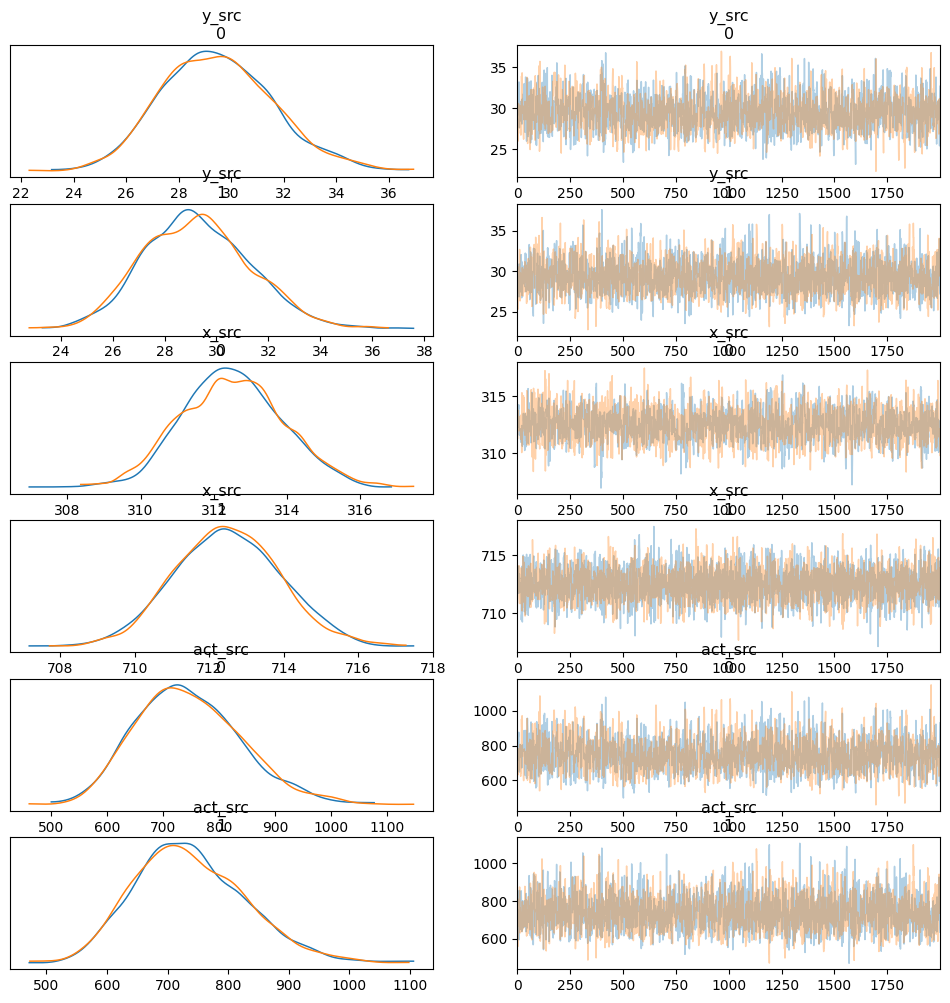

In [31]:
az.plot_trace(trace, compact=False)

In [32]:
try:
    nchains, ndraws = trace["posterior"].bkg.shape
    bkg_samples = trace["posterior"].bkg.stack(sample=("chain", "draw")).values.flatten()
    print(nchains, ndraws)
except AttributeError:
    print("Background was set to {}".format(MEAN_BKG_CPS))

Background was set to 14.81


In [32]:
x_samples = posterior.x_src.stack(sample=("chain","draw")).transpose("sources","sample").values
y_samples = posterior.y_src.stack(sample=("chain","draw")).transpose("sources","sample").values
a_samples = posterior.act_src.stack(sample=("chain","draw")).transpose("sources","sample").values

samples = np.concatenate([x_samples, y_samples, a_samples], axis=0)
samples

array([[312.85378609, 314.79713491, 314.57431297, ..., 312.12026862,
        313.15630362, 311.44315165],
       [713.41772508, 710.50022822, 715.96240259, ..., 710.12031266,
        712.45618105, 712.47740075],
       [ 27.37385685,  25.87633699,  25.78407105, ...,  29.04968375,
         30.59896215,  29.5087665 ],
       [ 31.53563664,  28.85663556,  28.424415  , ...,  30.42073239,
         32.08990774,  32.31017789],
       [611.84993593, 631.54810933, 629.98879338, ..., 753.69290146,
        770.8005073 , 757.48749086],
       [864.39948617, 693.07538372, 706.13245979, ..., 826.27313918,
        846.27295385, 850.06527689]], shape=(6, 4000))

In [33]:
cov_matrix = np.cov(samples)
print("Covariance matrix:")
print(cov_matrix)

Covariance matrix:
[[ 2.09523566e+00 -7.24263194e-03 -4.64210243e-02  1.13784639e-01
  -3.09244988e+00  4.73713777e+00]
 [-7.24263194e-03  2.07537637e+00 -9.77633598e-02  9.84856830e-02
  -4.31167651e+00  3.85702161e+00]
 [-4.64210243e-02 -9.77633598e-02  4.62881819e+00 -2.79060940e-01
   1.92502146e+02 -9.67339605e+00]
 [ 1.13784639e-01  9.84856830e-02 -2.79060940e-01  4.38843293e+00
  -1.15386772e+01  1.81522982e+02]
 [-3.09244988e+00 -4.31167651e+00  1.92502146e+02 -1.15386772e+01
   9.04191815e+03 -4.40553363e+02]
 [ 4.73713777e+00  3.85702161e+00 -9.67339605e+00  1.81522982e+02
  -4.40553363e+02  8.56800192e+03]]


In [34]:
corr_matrix = np.corrcoef(samples)
print("Correlation matrix:")
print(corr_matrix)

Correlation matrix:
[[ 1.         -0.00347321 -0.01490607  0.03752429 -0.02246756  0.03535573]
 [-0.00347321  1.         -0.03154225  0.03263397 -0.03147512  0.02892437]
 [-0.01490607 -0.03154225  1.         -0.06191691  0.94095797 -0.04857403]
 [ 0.03752429  0.03263397 -0.06191691  1.         -0.05792566  0.93613204]
 [-0.02246756 -0.03147512  0.94095797 -0.05792566  1.         -0.05005281]
 [ 0.03535573  0.02892437 -0.04857403  0.93613204 -0.05005281  1.        ]]


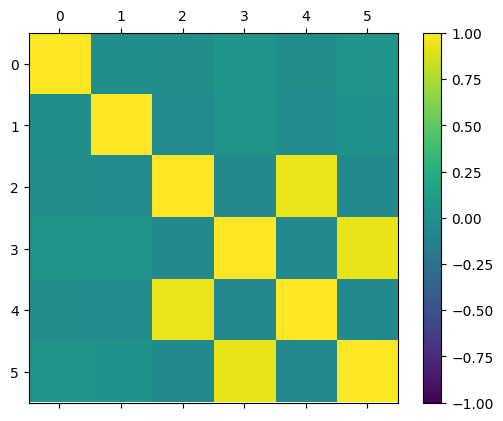

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(corr_matrix, vmin=-1, vmax=1)
fig.colorbar(cax)

In [36]:
samples_len, w = samples.shape
print(samples_len, w)

6 4000


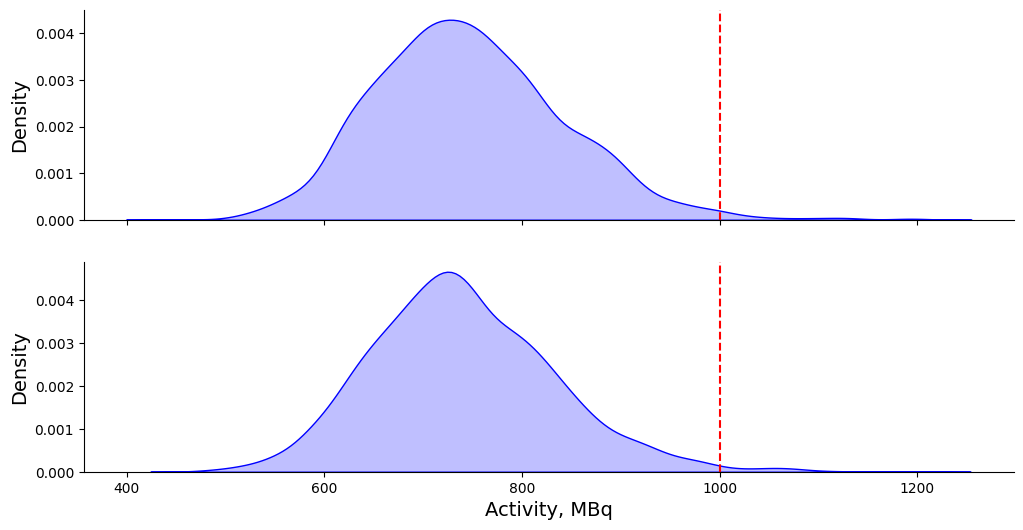

In [37]:
plot_act_density(act_samples, true_act=true_acts)

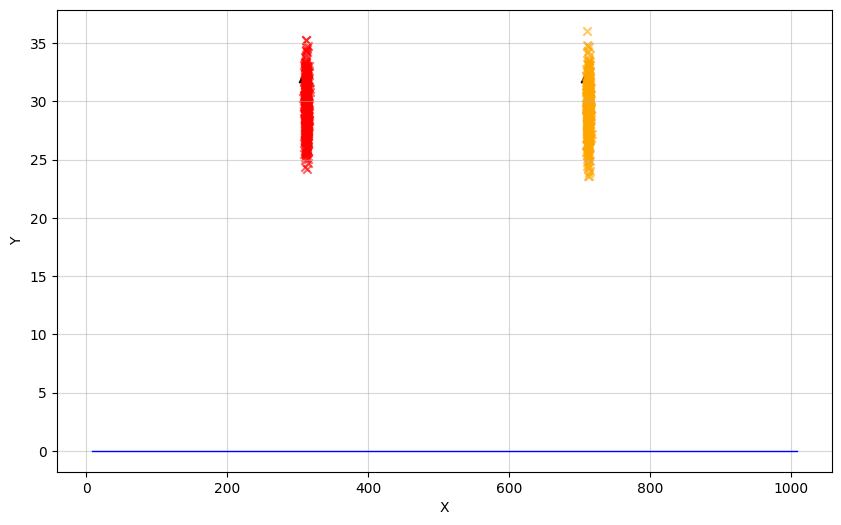

In [38]:
plot_location(
    df,
    ref_coords_x,
    ref_coords_y,
    x_samples,
    y_samples
)

In [39]:
import numpy as np
from dataclasses import dataclass
from typing import Tuple


@dataclass
class PositionResolver:
    road_start: Tuple[float, float] = (0, 0)
    road_end: Tuple[float, float] = (1169, 1169)

    def _line_params(self):
        x1, y1 = self.road_start
        x2, y2 = self.road_end

        A = y2 - y1
        B = x1 - x2
        C = x2*y1 - x1*y2
        return A, B, C

    def _distance_samples(self, x_samples, y_samples):
        A, B, C = self._line_params()
        numerator = np.abs(A*x_samples + B*y_samples + C)
        denominator = np.sqrt(A*A + B*B)
        return numerator / denominator

    def distance_stats(self, x_samples, y_samples) -> Dict[str, float]:
        d_samples = self._distance_samples(x_samples, y_samples)

        return {
            "mean": np.mean(d_samples),
            "std": np.std(d_samples),
            "median": np.median(d_samples),
            "hdi_3%": np.quantile(d_samples, 0.03),
            "hdi_97%": np.quantile(d_samples, 0.97),
        }

    def resolve_distance(self, x_samples, y_samples):
        d_samples = self._distance_samples(x_samples, y_samples)
        return np.median(d_samples)

    def resolve_all_sources(self, x_samples, y_samples):
        """
        x_samples: shape (n_sources, n_draws)
        y_samples: shape (n_sources, n_draws)
        """
        n_sources = x_samples.shape[0]
        results = []

        for i in range(n_sources):
            stats = self.distance_stats(
                x_samples[i],
                y_samples[i]
            )
            results.append(stats)

        return results

In [40]:
resolver = PositionResolver()

results = resolver.resolve_all_sources(x_samples, y_samples)

for i, r in enumerate(results):
    print(f"Source {i}:")
    print(r)


Source 0:
{'mean': np.float64(200.11887614241104), 'std': np.float64(1.8459674527666063), 'median': np.float64(200.17924612605506), 'hdi_3%': np.float64(196.3988502541213), 'hdi_97%': np.float64(203.4334579247405)}
Source 1:
{'mean': np.float64(483.06815419825796), 'std': np.float64(1.7699253124881438), 'median': np.float64(483.1426510281324), 'hdi_3%': np.float64(479.59734832455496), 'hdi_97%': np.float64(486.2839465301404)}


In [41]:
pred_cps = np.array(trace.posterior_predictive.predicted_cps)
pred_cps_reshaped = np.vstack(([item for item in pred_cps]))
cps_ = df.ROI_P

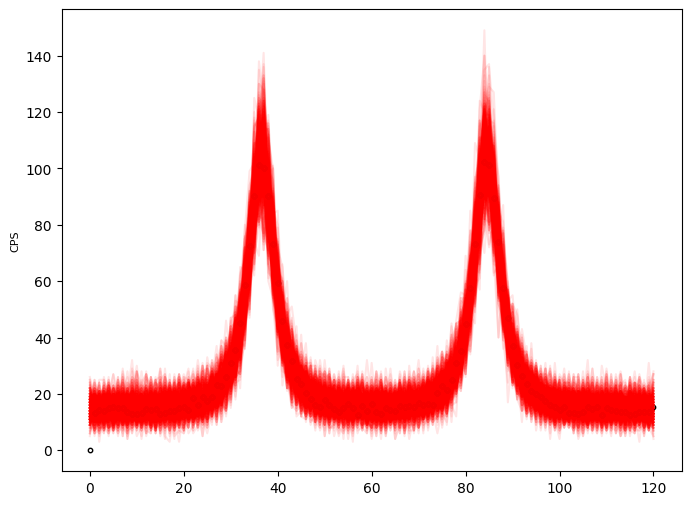

In [42]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df.index, cps_, c="w", ec="black",s=10)
step = 10
for j in range(0, len(pred_cps_reshaped), step):
    ax.plot(pred_cps_reshaped[j], c="r", alpha=.1)        
            
ax.set_ylabel("CPS", fontsize=8)
plt.show()

#### 📊 Residual analysis
✅ No trend -> this is for good if the distribution is symetrical around 0</br>
✅ Dispersion. Width of the residuals cloud. Within +-1 is OK </br>
✅ Homoscedasticity. The same distribution throughout the axis </br>
✅ Outliers. The problem is when many >3 -> model does not explain the data </br>
✅ Structure in time. Problem: patterns, waves, model error systematics </br>
✅ Quick check:

```
np.var(y - lambda_mean) / np.mean(lambda_mean)
```
Ok: ≈ 1 </br>
Issue: 1 → overdispersion </br>

In [43]:
lambda_mean = pred_cps_reshaped.mean(axis=0)
residuals = (cps_ - lambda_mean)/np.sqrt(lambda_mean)
print(residuals)


0     -3.854413
1     -0.440414
2     -0.141059
3     -0.279139
4      0.027394
         ...   
116   -0.492394
117   -0.303102
118   -0.385084
119   -0.315253
120    0.150076
Name: ROI_P, Length: 121, dtype: float64


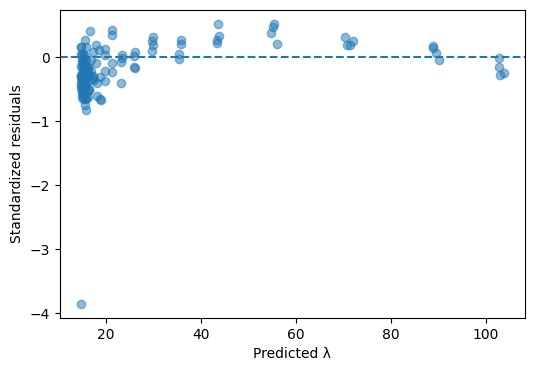

In [44]:
plt.figure(figsize=(6,4))
plt.scatter(lambda_mean, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted λ")
plt.ylabel("Standardized residuals")
plt.show()

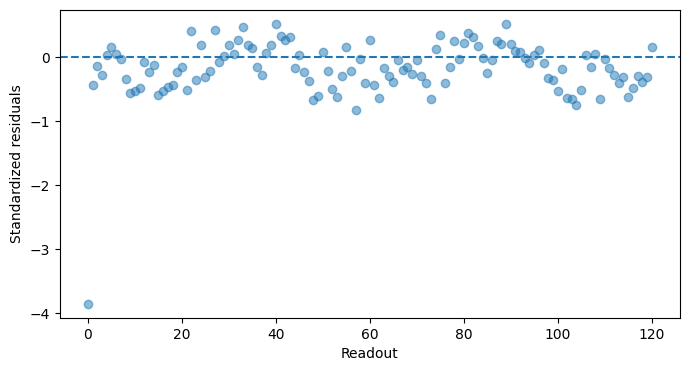

In [45]:
plt.figure(figsize=(8,4))
plt.scatter(range(len(residuals)), residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Readout")
plt.ylabel("Standardized residuals")
plt.show()